In [87]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

In [88]:
model = joblib.load("../models/xgboost_v1.pkl")
feature_importances = pd.read_csv("../models/info/xgboost_v1/xgboost_v1_features.csv", index_col="feature")
mae_by_hours_ahead = pd.read_csv("../models/info/xgboost_v1/xgboost_v1_abs_error_by_hours_ahead.csv", index_col="hours_ahead")
mae_by_month = pd.read_csv("../models/info/xgboost_v1/xgboost_v1_abs_error_by_month.csv")

baseline_mae_by_hours_ahead = pd.read_csv("../models/info/xgboost_v1/xgboost_v1_baseline_abs_error_by_hours_ahead.csv", index_col="hours_ahead")

In [89]:
feature_importances.sort_values(by="importance", ascending=False).head(20)

,importance
feature,
price,0.627788
hours_ahead,0.214325
price_diff_1h,0.157887


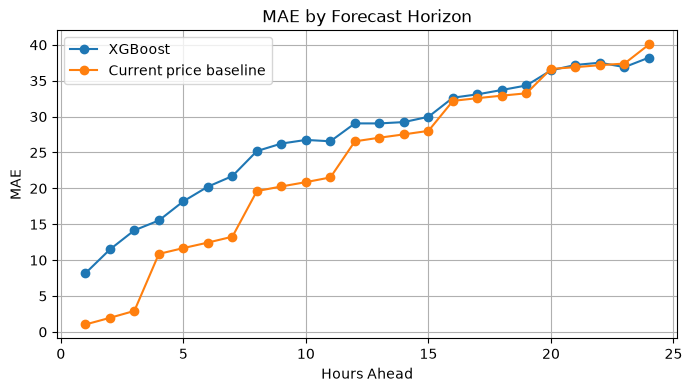

In [90]:
plt.figure(figsize=(8, 4))

plt.plot(
    mae_by_hours_ahead,
    marker="o",
    label="XGBoost"
)

plt.plot(
    baseline_mae_by_hours_ahead,
    marker="o",
    label="Current price baseline"
)

plt.xlabel("Hours Ahead")
plt.ylabel("MAE")
plt.title("MAE by Forecast Horizon")
plt.grid(True)
plt.legend()

plt.show()

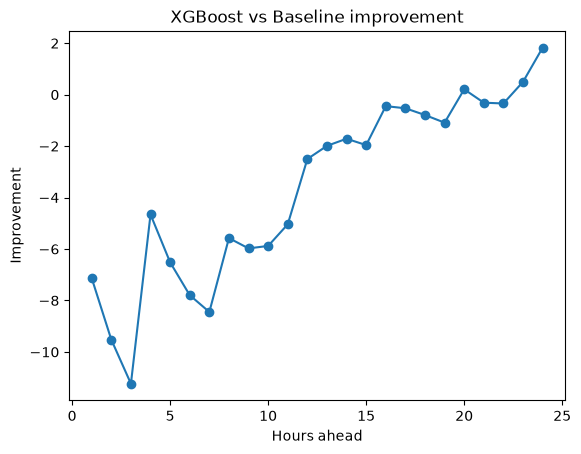

In [91]:
improvement = (
    baseline_mae_by_hours_ahead["baseline_abs_error"]
    - mae_by_hours_ahead["abs_error"]
).rename("improvement")

plt.plot(
    improvement,
    marker="o"
)

plt.title("XGBoost vs Baseline improvement")
plt.ylabel("Improvement")
plt.xlabel("Hours ahead")

plt.show()

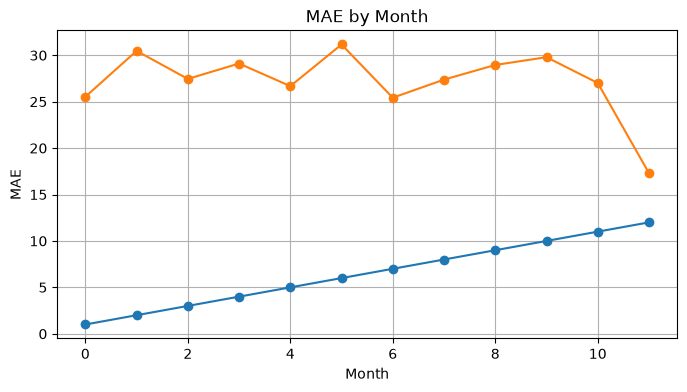

In [92]:
plt.figure(figsize=(8, 4))
plt.plot(
    mae_by_month.index,
    mae_by_month.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("MAE")
plt.title("MAE by Month")
plt.grid(True)
plt.show()